In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Load model
model = joblib.load("energy_model.pkl")

# Load batch dataset
data = pd.read_excel("new_batches.xlsx")

# Extract features
feature_cols = model.feature_names_in_

X = data[feature_cols]
y_actual = data["Power_Consumption_kW"]

# Predictions
predictions = model.predict(X)

# Error
error = np.abs(y_actual - predictions)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


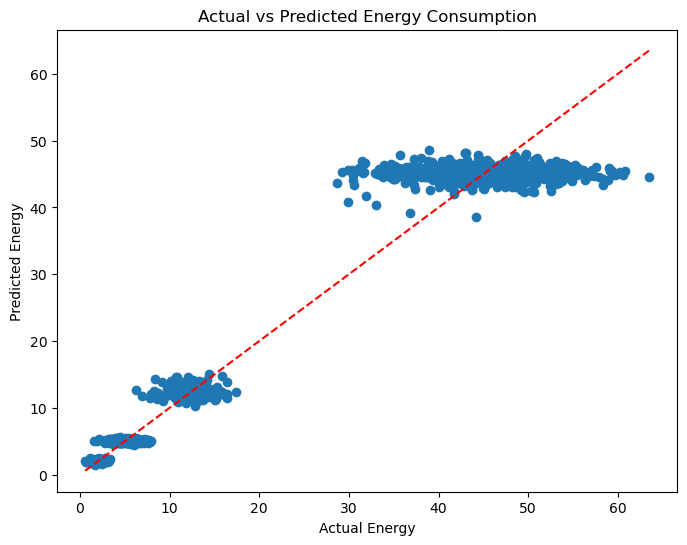

In [2]:
plt.figure(figsize=(8,6))

plt.scatter(y_actual, predictions)

plt.xlabel("Actual Energy")
plt.ylabel("Predicted Energy")
plt.title("Actual vs Predicted Energy Consumption")

plt.plot(
    [y_actual.min(), y_actual.max()],
    [y_actual.min(), y_actual.max()],
    'r--'
)

plt.show()

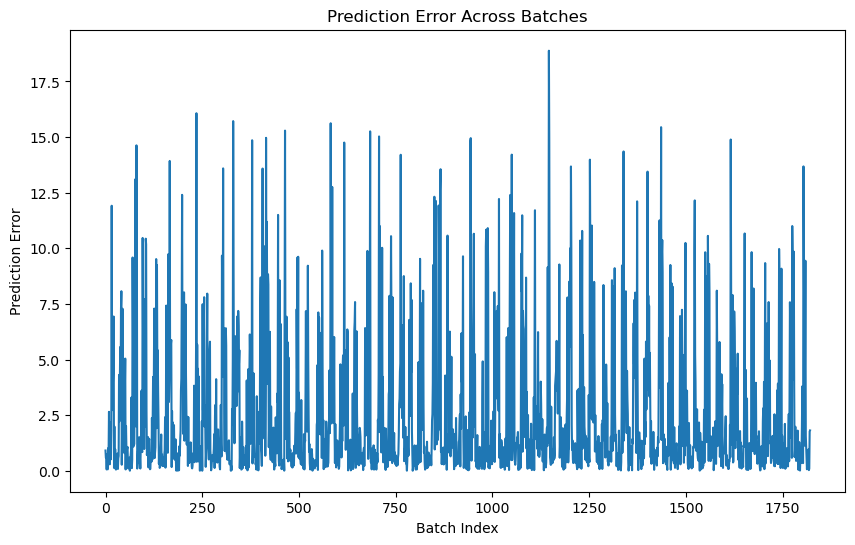

In [3]:
plt.figure(figsize=(10,6))

plt.plot(error)

plt.xlabel("Batch Index")
plt.ylabel("Prediction Error")

plt.title("Prediction Error Across Batches")

plt.show()

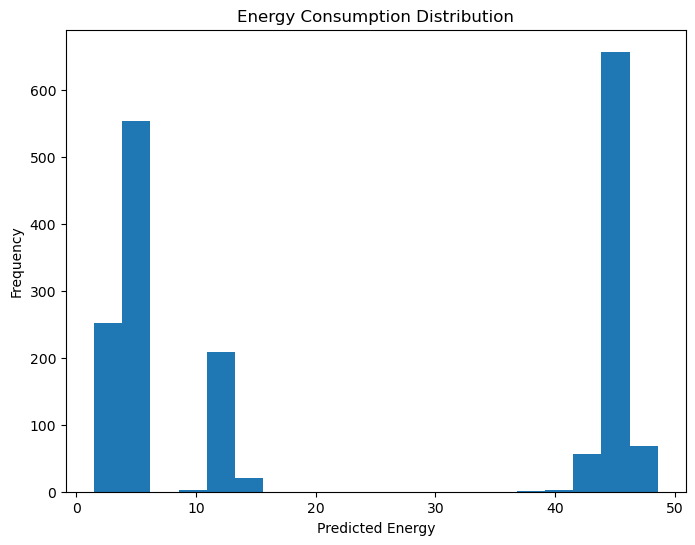

In [4]:
plt.figure(figsize=(8,6))

plt.hist(predictions, bins=20)

plt.xlabel("Predicted Energy")
plt.ylabel("Frequency")

plt.title("Energy Consumption Distribution")

plt.show()

In [5]:
mae = mean_absolute_error(y_actual, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.523120469382562


In [6]:
print(data["Power_Consumption_kW"].describe())

count    1822.000000
mean       22.588546
std        19.777420
min         0.593695
25%         4.681249
50%        12.055025
75%        43.211207
max        63.452715
Name: Power_Consumption_kW, dtype: float64
